# Library

In [83]:
!pip install scikeras

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns

In [85]:
from datetime import datetime as dt
from sklearn import metrics
from sklearn.model_selection import cross_val_score
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import ShuffleSplit
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

import joblib

import warnings
warnings.filterwarnings("ignore")

# EDA & Preprocessing

In [86]:
train=pd.read_csv('data/train.csv',parse_dates=['Date'])
features=pd.read_csv('data/features.csv',parse_dates=['Date'])
stores=pd.read_csv('data/stores.csv')

In [87]:
df1=pd.merge(features,stores,on=['Store'])
df1.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [88]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[ns]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-null   float64       
 5   MarkDown2     2921 non-null   float64       
 6   MarkDown3     3613 non-null   float64       
 7   MarkDown4     3464 non-null   float64       
 8   MarkDown5     4050 non-null   float64       
 9   CPI           7605 non-null   float64       
 10  Unemployment  7605 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
 12  Type          8190 non-null   object        
 13  Size          8190 non-null   int64         
dtypes: bool(1), datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 839.9+ KB


In [89]:
df1.drop(['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'],axis=1,inplace=True)

In [90]:
df1.head()

,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Type,Size
0,1,2010-02-05,42.31,2.572,211.096358,8.106,False,A,151315
1,1,2010-02-12,38.51,2.548,211.242170,8.106,True,A,151315
2,1,2010-02-19,39.93,2.514,211.289143,8.106,False,A,151315
3,1,2010-02-26,46.63,2.561,211.319643,8.106,False,A,151315
4,1,2010-03-05,46.50,2.625,211.350143,8.106,False,A,151315


In [91]:
df1.to_csv('all_features.csv',index=False)

In [92]:
data=pd.merge(train,df1,on=['Date','Store','IsHoliday'])
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [93]:
data.shape

(421570, 11)

In [94]:
y=[]
m=[]
d=[]
for dt in data['Date']:
    y.append(dt.year)
    m.append(dt.month)
    d.append(dt.day)

In [95]:
data['Year'] = pd.Series(y)
data['Month'] = pd.Series(m)
data['Day'] = pd.Series(d)

In [96]:
data.drop('Date',axis=1,inplace=True)

In [97]:
data.head()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Year,Month,Day
0,1,1,24924.50,False,42.31,2.572,211.096358,8.106,A,151315,2010,2,5
1,1,1,46039.49,True,38.51,2.548,211.242170,8.106,A,151315,2010,2,12
2,1,1,41595.55,False,39.93,2.514,211.289143,8.106,A,151315,2010,2,19
3,1,1,19403.54,False,46.63,2.561,211.319643,8.106,A,151315,2010,2,26
4,1,1,21827.90,False,46.50,2.625,211.350143,8.106,A,151315,2010,3,5


In [98]:
numeric_var_names=[key for key in dict(data.dtypes) if dict(data.dtypes)[key] in ['float64', 'int64', 'float32', 'int32']]
cat_var_names=[key for key in dict(data.dtypes) if dict(data.dtypes)[key] in ['object', 'O','bool']]

In [99]:
numeric_var_names

['Store',
 'Dept',
 'Weekly_Sales',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Size',
 'Year',
 'Month',
 'Day']

In [100]:
cat_var_names

['IsHoliday', 'Type']

In [101]:
data_num=data[numeric_var_names]
data_num.head(5)

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Size,Year,Month,Day
0,1,1,24924.50,42.31,2.572,211.096358,8.106,151315,2010,2,5
1,1,1,46039.49,38.51,2.548,211.242170,8.106,151315,2010,2,12
2,1,1,41595.55,39.93,2.514,211.289143,8.106,151315,2010,2,19
3,1,1,19403.54,46.63,2.561,211.319643,8.106,151315,2010,2,26
4,1,1,21827.90,46.50,2.625,211.350143,8.106,151315,2010,3,5


In [102]:
# Replace negative and 0 as missing
pd.set_option('mode.chained_assignment', None) # For SettingWithCopyWarning
data_num[data_num<=0]=np.nan

In [103]:
data_cat=data[cat_var_names]
data_cat.head(5)

,IsHoliday,Type
0,False,A
1,True,A
2,False,A
3,False,A
4,False,A


### Data Audit Report

In [104]:
# Creating Data audit Report
def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.std()/x.mean(), x.min(), x.dropna().quantile(0.01), x.dropna().quantile(0.05),x.dropna().quantile(0.10),x.dropna().quantile(0.25),x.dropna().quantile(0.50),x.dropna().quantile(0.75), x.dropna().quantile(0.90),x.dropna().quantile(0.95), x.dropna().quantile(0.99),x.max()],
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'CV','MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX'])

data_num.apply(var_summary).T

,N,NMISS,SUM,MEAN,MEDIAN,STD,VAR,CV,MIN,P1,P5,P10,P25,P50,P75,P90,P95,P99,MAX
Store,421570.0,0.0,9.359084e+06,22.200546,22.00000,12.785297,1.634638e+02,0.575900,1.000,1.000000,3.000000,5.000000,11.000000,22.00000,33.000000,40.000000,43.000000,45.000000,45.000000
Dept,421570.0,0.0,1.865882e+07,44.260317,37.00000,30.492054,9.297654e+02,0.688925,1.000,1.000000,4.000000,7.000000,18.000000,37.00000,74.000000,92.000000,95.000000,98.000000,99.000000
Weekly_Sales,420212.0,1358.0,6.737307e+09,16033.114591,7661.70000,22729.492116,5.166298e+08,1.417659,0.010,7.440000,67.551000,311.186000,2120.130000,7661.70000,20271.265000,42922.748000,61275.522000,106566.351400,693099.360000
Temperature,421501.0,69.0,2.533231e+07,60.100233,62.09000,18.432294,3.397495e+02,0.306693,5.540,18.360000,27.310000,33.990000,46.700000,62.09000,74.280000,83.580000,87.270000,92.810000,100.140000
Fuel_Price,421570.0,0.0,1.416908e+06,3.361027,3.45200,0.458515,2.102356e-01,0.136421,2.472,2.565000,2.653000,2.720000,2.933000,3.45200,3.738000,3.917000,4.029000,4.202000,4.468000
CPI,421570.0,0.0,7.217360e+07,171.201947,182.31878,39.159276,1.533449e+03,0.228731,126.064,126.111903,126.496258,128.823806,132.022667,182.31878,212.416993,219.444244,221.941558,225.473509,227.232807
Unemployment,421570.0,0.0,3.355819e+06,7.960289,7.86600,1.863296,3.471872e+00,0.234074,3.879,4.156000,5.326000,5.965000,6.891000,7.86600,8.572000,9.816000,12.187000,14.180000,14.313000
Size,421570.0,0.0,5.764039e+10,136727.915739,140167.00000,60980.583328,3.718632e+09,0.446000,34875.000,34875.000000,39690.000000,39910.000000,93638.000000,140167.00000,202505.000000,204184.000000,206302.000000,219622.000000,219622.000000
Year,421570.0,0.0,8.477640e+08,2010.968591,2011.00000,0.796876,6.350114e-01,0.000396,2010.000,2010.000000,2010.000000,2010.000000,2010.000000,2011.00000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000
Month,421570.0,0.0,2.718920e+06,6.449510,6.00000,3.243217,1.051846e+01,0.502863,1.000,1.000000,1.000000,2.000000,4.000000,6.00000,9.000000,11.000000,12.000000,12.000000,12.000000


In [105]:
num_summary=data_num.apply(var_summary).T
num_summary.to_csv('num_summary.csv')

In [106]:
def cat_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.value_counts()],
                  index=['N', 'NMISS', 'ColumnsNames'])

cat_summary=data_cat.apply(cat_summary)

In [107]:
cat_summary

,IsHoliday,Type
N,421570,421570
NMISS,0,0
ColumnsNames,IsHoliday False 391909 True 29661 Name...,Type A 215478 B 163495 C 42597 Name:...


### Handling Outlier

In [108]:
#Handling Outliers
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.99))
    x = x.clip(lower=x.quantile(0.01))
    return x

data_num=data_num.apply(outlier_capping)

### Handling Missing

In [109]:
#Handling missings
def Missing_imputation(x):
    x = x.fillna(x.median())
    return x

data_num=data_num.apply(Missing_imputation)

### Dummy Creation

In [110]:
# An utility function to create dummy variable
def create_dummies( df, colname ):
    col_dummies = pd.get_dummies(df[colname], prefix=colname, drop_first=True)
    df = pd.concat([df, col_dummies], axis=1)
    df.drop( colname, axis = 1, inplace = True )
    return df

In [111]:
for c_feature in ['IsHoliday', 'Type']:
    data_cat.loc[:,c_feature] = data_cat[c_feature].astype('category')
    data_cat = create_dummies(data_cat , c_feature )

data_cat.head()

,IsHoliday_True,Type_B,Type_C
0,False,False,False
1,True,False,False
2,False,False,False
3,False,False,False
4,False,False,False


### Final file for analysis

In [112]:
data = pd.concat([data_num, data_cat], axis=1)
data.head()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Size,Year,Month,Day,IsHoliday_True,Type_B,Type_C
0,1,1,24924.50,42.31,2.572,211.096358,8.106,151315,2010,2,5,False,False,False
1,1,1,46039.49,38.51,2.565,211.242170,8.106,151315,2010,2,12,True,False,False
2,1,1,41595.55,39.93,2.565,211.289143,8.106,151315,2010,2,19,False,False,False
3,1,1,19403.54,46.63,2.565,211.319643,8.106,151315,2010,2,26,False,False,False
4,1,1,21827.90,46.50,2.625,211.350143,8.106,151315,2010,3,5,False,False,False


In [113]:
# correlation matrix (ranges from 1 to -1)
corrm=data.corr()
corrm.to_csv('corrm.csv')
corrm

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Size,Year,Month,Day,IsHoliday_True,Type_B,Type_C
Store,1.000000,0.024011,-0.083732,-0.052251,0.064984,-0.210949,0.208671,-0.182881,0.002997,0.001011,-0.000015,-0.000548,-0.233461,0.439004
Dept,0.024011,1.000000,0.143319,0.004383,0.003514,-0.007483,0.007874,-0.003022,0.003688,0.000894,-0.000664,0.000906,-0.029920,0.028344
Weekly_Sales,-0.083732,0.143319,1.000000,0.000576,0.001502,-0.022807,-0.025323,0.252590,-0.009287,0.025578,-0.007982,0.007948,-0.134705,-0.099054
Temperature,-0.052251,0.004383,0.000576,1.000000,0.142011,0.184608,0.095511,-0.059287,0.066476,0.234499,0.025848,-0.156730,-0.107740,0.135709
Fuel_Price,0.064984,0.003514,0.001502,0.142011,1.000000,-0.162609,-0.034938,0.004468,0.780315,-0.042186,0.028013,-0.077839,0.037372,0.001369
CPI,-0.210949,-0.007483,-0.022807,0.184608,-0.162609,1.000000,-0.300190,-0.003307,0.074335,0.005130,0.002701,-0.001934,-0.081883,-0.006557
Unemployment,0.208671,0.007874,-0.025323,0.095511,-0.034938,-0.300190,1.000000,-0.068099,-0.236754,-0.012963,-0.003802,0.010305,-0.013574,0.175291
Size,-0.182881,-0.003022,0.252590,-0.059287,0.004468,-0.003307,-0.068099,1.000000,-0.004975,-0.001210,-0.000386,0.000593,-0.455646,-0.528852
Year,0.002997,0.003688,-0.009287,0.066476,0.780315,0.074335,-0.236754,-0.004975,1.000000,-0.194288,0.005835,-0.056746,-0.000732,0.005244
Month,0.001011,0.000894,0.025578,0.234499,-0.042186,0.005130,-0.012963,-0.001210,-0.194288,1.000000,0.016363,0.123376,0.000019,-0.000092


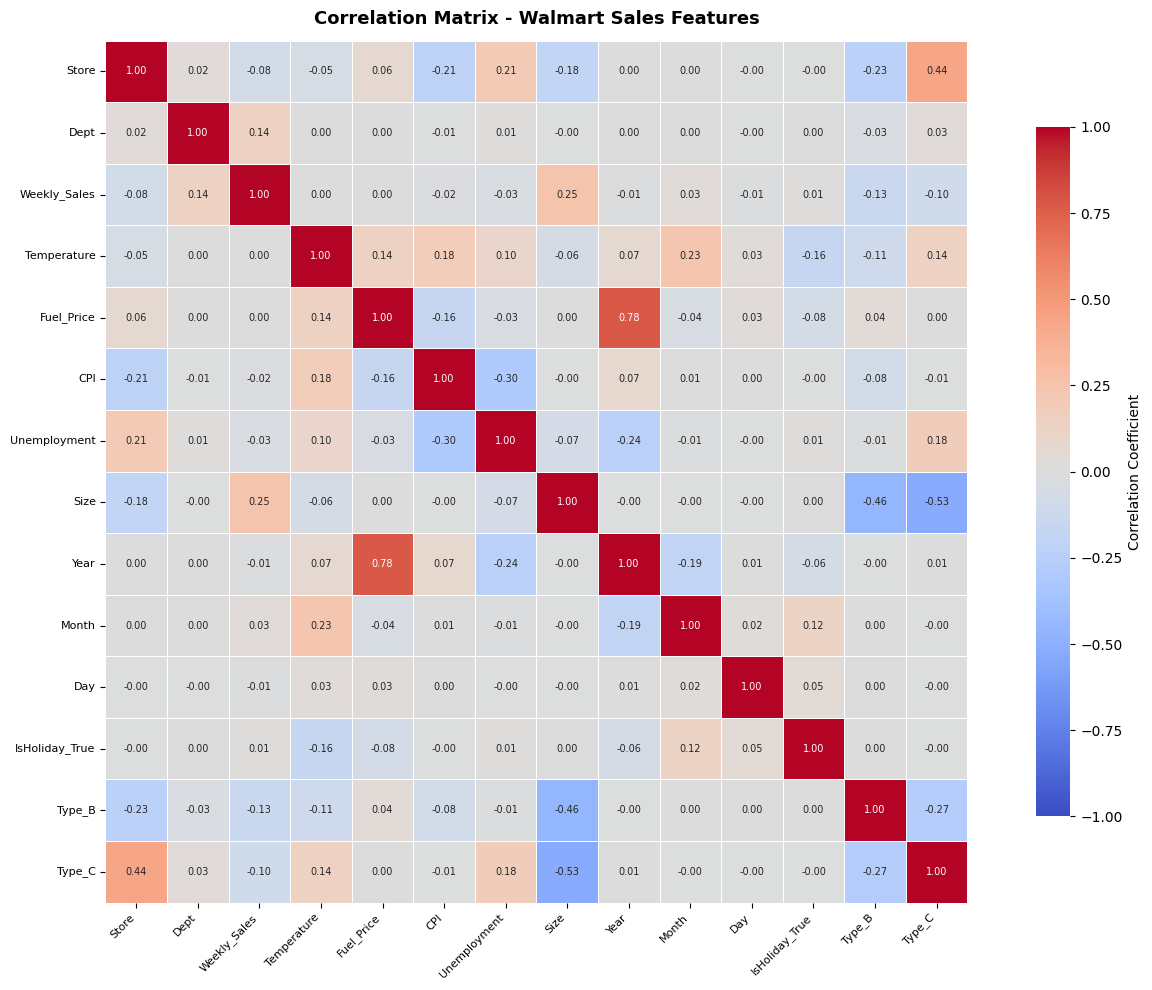

In [114]:
# Correlation matrix with annotation
plt.figure(figsize=(14, 10))
corr = data.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix - Walmart Sales Features', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [115]:
data.drop('Type_C',axis=1,inplace=True)

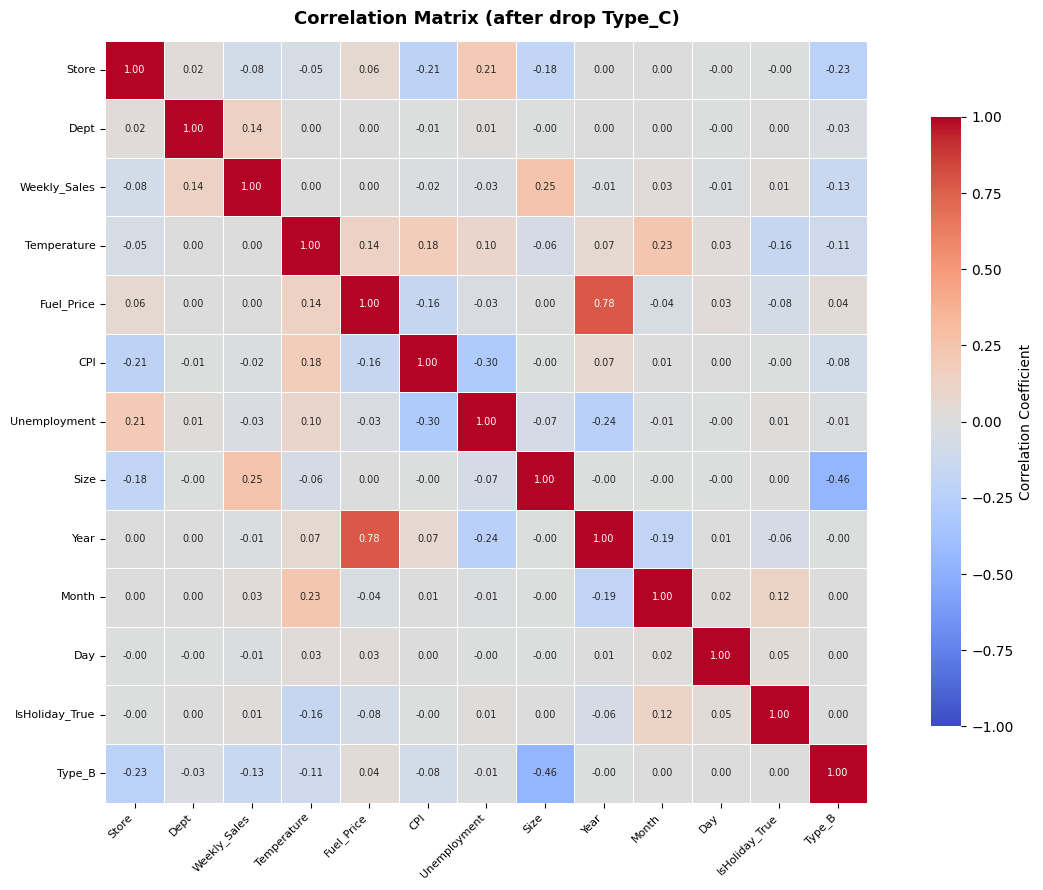

In [116]:
# Correlation matrix after drop Type_C
plt.figure(figsize=(13, 9))
corr2 = data.corr()

sns.heatmap(
    corr2,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix (after drop Type_C)', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [117]:
data.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'Size', 'Year', 'Month', 'Day', 'IsHoliday_True',
       'Type_B'],
      dtype='object')

### Model Building

In [118]:
lm=smf.ols('Weekly_Sales~Store+Dept+Weekly_Sales+Temperature+Fuel_Price+CPI+Unemployment+Size+Year+Month+Day+IsHoliday_True', data).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.212e+31
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:09:05   Log-Likelihood:             8.2178e+06
No. Observations:              421570   AIC:                        -1.644e+07
Df Residuals:                  421557   BIC:                        -1.644e+07
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               2.75

In [119]:
data.drop('Type_B',axis=1,inplace=True)

In [120]:
X=data[data.columns.difference(['Weekly_Sales'])]
y=data['Weekly_Sales']

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Tree

In [122]:
regressor = DecisionTreeRegressor(max_depth=5,random_state=0)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=0)

In [123]:
pred=regressor.predict(X_train)
y_pred=regressor.predict(X_test)

In [124]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 9145.257041898783
Mean Squared Error: 192332068.63084176
Root Mean Squared Error: 13868.383778611038


In [125]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 9177.598768122753
Mean Squared Error: 193167074.29474044
Root Mean Squared Error: 13898.455824110117


In [126]:
from sklearn.metrics import r2_score

print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.5539828660028754
R-squared for Test: 0.5528359126879683


### Tuning a regression tree

In [127]:
# list of values to try
max_depth_range = range(5, 15)

# list to store the average RMSE for each value of max_depth
RMSE_Scores = []
MSE_Scores = []

# use LOOCV with each value of max_depth
for depth in max_depth_range:
    treereg = DecisionTreeRegressor(max_depth=depth, random_state=345)

    MSE_scores = cross_val_score(treereg, X_train, y_train, scoring='neg_mean_squared_error')

    RMSE_Scores.append(np.mean(np.sqrt(-MSE_scores)))
    MSE_Scores.append(MSE_scores)

In [128]:
print (RMSE_Scores)

[np.float64(13879.719881611905), np.float64(11056.966940995324), np.float64(10071.28342663819), np.float64(9162.092645626446), np.float64(8323.610416874799), np.float64(7402.689432054516), np.float64(6537.198777528016), np.float64(5839.292861122634), np.float64(5196.5718956209375), np.float64(4737.93020445316)]


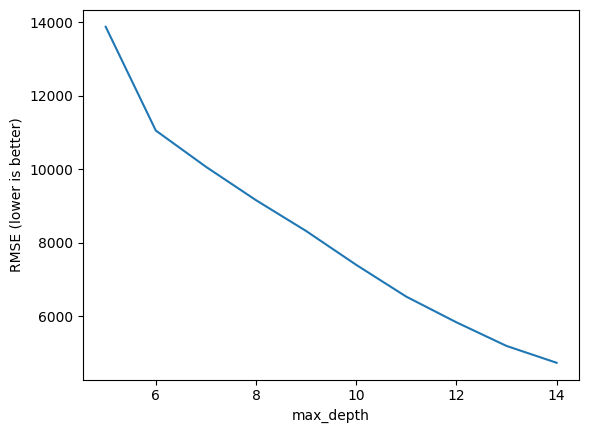

In [129]:
# plot max_depth (x-axis) versus RMSE (y-axis)
plt.plot(max_depth_range, RMSE_Scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE (lower is better)')
plt.show()

### Building Final Decision Tree Model

In [130]:
# max_depth=11 was best, so fit a tree using that parameter
treereg = DecisionTreeRegressor(max_depth=14, random_state=345)
treereg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=14, random_state=345)

In [131]:
treereg.feature_importances_

array([2.36179525e-02, 7.28499939e-03, 6.83358021e-01, 1.68787384e-03,
       1.38719984e-03, 1.69391383e-02, 1.89252892e-01, 6.36291334e-02,
       4.87481053e-03, 7.57401979e-03, 3.93959683e-04])

In [132]:
# "Gini importance" of each feature: the (normalized) total reduction of error brought by that feature
pd.DataFrame({'feature':data.columns.difference(['Weekly_Sales']), 'importance':treereg.feature_importances_})

,feature,importance
0,CPI,0.023618
1,Day,0.007285
2,Dept,0.683358
3,Fuel_Price,0.001688
4,IsHoliday_True,0.001387
5,Month,0.016939
6,Size,0.189253
7,Store,0.063629
8,Temperature,0.004875
9,Unemployment,0.007574


## Creating a tree diagram

In [133]:
# create a Graphviz file
from sklearn.tree import export_graphviz
export_graphviz(treereg, out_file='tree_vehicles.png', feature_names=data.columns.difference(['Weekly_Sales']))

## Making predictions

In [134]:
pred=treereg.predict(X_train)
y_pred=treereg.predict(X_test)

In [135]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 2041.5165842990527
Mean Squared Error: 15729169.345961288
Root Mean Squared Error: 3966.001682546452


In [136]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 2355.453541097146
Mean Squared Error: 21290797.958956957
Root Mean Squared Error: 4614.195266669688


In [137]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9635241326015869
R-squared for Test: 0.9507137524745278


# Random Forest (RF)

In [138]:
rfr = RandomForestRegressor(max_depth=5,n_estimators=20, random_state=0)
rfr.fit(X_train, y_train)
pred = rfr.predict(X_train)

In [139]:
y_pred= rfr.predict(X_test)

In [140]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 9112.615193344995
Mean Squared Error: 191590025.02633145
Root Mean Squared Error: 13841.604857325305


In [141]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 9147.59553607459
Mean Squared Error: 192546102.52754837
Root Mean Squared Error: 13876.098245816378


In [142]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.5557036615214834
R-squared for Test: 0.5542734054622249


### Tuning a Random Forest

In [143]:
from sklearn.model_selection import GridSearchCV

In [144]:
param_grid={'max_depth': range(5,15),
            'n_estimators': (10, 50)}

In [145]:
# Perform Grid-Search
gsc = GridSearchCV(estimator=RandomForestRegressor(),param_grid=param_grid, verbose=0, n_jobs=-1)

grid_result = gsc.fit(X_train, y_train)

In [146]:
grid_result.best_score_

np.float64(0.9606214929568558)

In [147]:
grid_result.best_params_

{'max_depth': 14, 'n_estimators': 50}

### Building Final Random Forest Model

In [148]:
rfr = RandomForestRegressor(max_depth=14,n_estimators=50, random_state=0)
rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=14, n_estimators=50, random_state=0)

In [149]:
pred = rfr.predict(X_train)
y_pred = rfr.predict(X_test)

In [150]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 1921.4216533167446
Mean Squared Error: 13259126.111445336
Root Mean Squared Error: 3641.3082966765305


In [151]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 2158.2578133613965
Mean Squared Error: 17123165.549061134
Root Mean Squared Error: 4138.014686907374


In [152]:
from sklearn.metrics import r2_score

print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9692521508782599
R-squared for Test: 0.9603614398437507


# Gradient Boosting (GBM)

In [153]:
gbrt=GradientBoostingRegressor()
gbrt.fit(X_train, y_train)

GradientBoostingRegressor()

In [154]:
pred=gbrt.predict(X_train)
y_pred=gbrt.predict(X_test)

In [155]:
#One of the benefits of growing trees is that we can understand how important each of the features are
print(gbrt.feature_importances_)

[8.41962440e-03 3.91742659e-04 7.56893138e-01 1.33860504e-06
 3.83312462e-04 2.50511115e-03 1.94325834e-01 3.53524270e-02
 4.90632028e-04 1.20221093e-03 3.46283629e-05]


In [156]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 6596.780468548503
Mean Squared Error: 101324484.2162159
Root Mean Squared Error: 10066.006368774853


In [157]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 6661.585430149561
Mean Squared Error: 103823313.13689314
Root Mean Squared Error: 10189.372558548104


In [158]:
from sklearn.metrics import r2_score

print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.7650290127092899
R-squared for Test: 0.7596585379259213


### Tuning a Gradient Boosting Model (GBM)

In [159]:
param_grid={'learning_rate' : [0.02,0.05,0.1,0.01],# 0.02,0.05,0.1],
            'max_depth' : [4,5,6]}# 5,6]

In [160]:
# Perform Grid-Search
gbr = GridSearchCV(estimator=GradientBoostingRegressor(),param_grid=param_grid)

grid_result = gbr.fit(X_train, y_train)

In [161]:
grid_result.best_score_

np.float64(0.9102742671220734)

In [162]:
grid_result.best_params_

{'learning_rate': 0.1, 'max_depth': 6}

### Building Final Gradient Boosting Model

In [163]:
gbrt=GradientBoostingRegressor(learning_rate=0.01, max_depth=6)
gbrt.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, max_depth=6)

In [164]:
pred=gbrt.predict(X_train)
y_pred=gbrt.predict(X_test)

In [165]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 8783.487998672386
Mean Squared Error: 157159224.44013366
Root Mean Squared Error: 12536.316222883564


In [166]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 8823.577123391799
Mean Squared Error: 159398914.9682369
Root Mean Squared Error: 12625.328311304895


In [167]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.6355485210293269
R-squared for Test: 0.6310061091387532


# XGBOOST

In [168]:
warnings.filterwarnings("ignore", category=FutureWarning)
xg_reg = xgb.XGBRegressor(objective='reg:squarederror')
xg_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [169]:
pred=xg_reg.predict(X_train)
y_pred=xg_reg.predict(X_test)

In [170]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 2767.488903875319
Mean Squared Error: 20408023.43704571
Root Mean Squared Error: 4517.524038347301


In [171]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 2856.8736823375125
Mean Squared Error: 22254882.219408434
Root Mean Squared Error: 4717.508051864716


In [172]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9526738926652523
R-squared for Test: 0.9484819856996224


### Tuning a XGBoost Model

In [173]:
xgb1 = xgb.XGBRegressor(objective='reg:squarederror')

In [174]:
parameters = {'learning_rate': [0.01,0.1], #so called `eta` value
              'max_depth': [4,5,6]}

In [175]:
xgb_grid = GridSearchCV(xgb1,parameters,n_jobs = 5,verbose=True)

grid_result = xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [176]:
print(xgb_grid.best_score_)

0.9108366261665445


In [177]:
print(xgb_grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 6}


### Building Final XGBoost Model

In [178]:
xg_reg = xgb.XGBRegressor(learning_rate=0.1, max_depth=6,objective='reg:squarederror')
xg_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [179]:
pred=xg_reg.predict(X_train)
y_pred=xg_reg.predict(X_test)

In [180]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 3743.863168416007
Mean Squared Error: 37531186.10453154
Root Mean Squared Error: 6126.270162548461


In [181]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 3814.9276965765757
Mean Squared Error: 39642386.9466676
Root Mean Squared Error: 6296.220052274824


In [182]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9129653615176083
R-squared for Test: 0.9082315045532597


# KNN

In [183]:
knn = neighbors.KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [184]:
pred=knn.predict(X_train)
y_pred=knn.predict(X_test)

In [185]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 8649.679101904783
Mean Squared Error: 176266412.7816323
Root Mean Squared Error: 13276.536174079152


In [186]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 10535.213535267058
Mean Squared Error: 260609512.71699914
Root Mean Squared Error: 16143.404619751038


In [187]:
from sklearn.metrics import r2_score

print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.5912390439697539
R-squared for Test: 0.39671284392330175


### Tuning a KNN Model

In [188]:
rmse_val = [] #to store rmse values for different k
for K in range(20):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    y_pred=model.predict(X_test) #make prediction on test set
    error = sqrt(mean_squared_error(y_test,y_pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 22335.179177523707
RMSE value for k=  2 is: 18704.8034873556
RMSE value for k=  3 is: 17389.993564623597
RMSE value for k=  4 is: 16614.678746045138
RMSE value for k=  5 is: 16143.404619751038
RMSE value for k=  6 is: 15873.858132835328
RMSE value for k=  7 is: 15689.518800487753
RMSE value for k=  8 is: 15574.09871338437
RMSE value for k=  9 is: 15495.192912088218
RMSE value for k=  10 is: 15440.09840675658
RMSE value for k=  11 is: 15403.846441579204
RMSE value for k=  12 is: 15376.692705938476
RMSE value for k=  13 is: 15347.097619352611
RMSE value for k=  14 is: 15338.125841529238
RMSE value for k=  15 is: 15332.155270580855
RMSE value for k=  16 is: 15330.608021471298
RMSE value for k=  17 is: 15327.296130309931
RMSE value for k=  18 is: 15323.801767314662
RMSE value for k=  19 is: 15323.397713655255
RMSE value for k=  20 is: 15328.173107543966


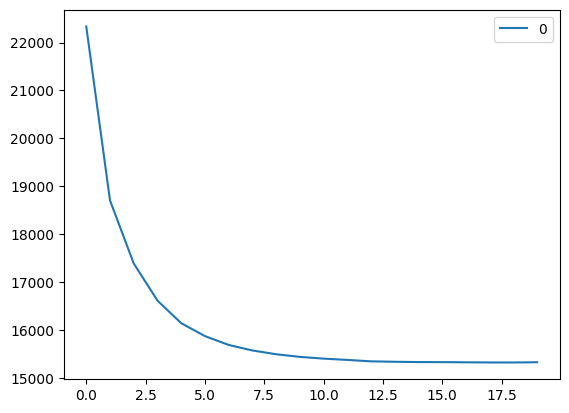

In [189]:
#plotting the rmse values against k values
curve = pd.DataFrame(rmse_val) #elbow curve
curve.plot()
plt.show()

### Building Final KNN Model

In [190]:
knn = neighbors.KNeighborsRegressor(n_neighbors=9)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=9)

In [191]:
pred=knn.predict(X_train)
y_pred=knn.predict(X_test)

In [192]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 9069.017911785912
Mean Squared Error: 190593460.14769801
Root Mean Squared Error: 13805.559030611474


In [193]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 10177.483095370653
Mean Squared Error: 240101003.38282892
Root Mean Squared Error: 15495.192912088218


In [194]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.5580146906398954
R-squared for Test: 0.44418816492211544


# Neural Network

In [195]:
def build_regressor():
    regressor = Sequential()
    regressor.add(Dense(units=1, input_dim=11))
    regressor.add(Dense(units=1))
    regressor.compile(optimizer='adam', loss='mean_squared_error',  metrics=['mae'])
    return regressor

In [196]:
regressor = KerasRegressor(build_fn=build_regressor, batch_size=256,epochs=10)

In [197]:
results=regressor.fit(X_train,y_train)

Epoch 1/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 551571840.0000 - mae: 15534.5244
Epoch 2/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 404442272.0000 - mae: 13968.3818
Epoch 3/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 404244672.0000 - mae: 13976.9277
Epoch 4/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 403982112.0000 - mae: 13994.1025
Epoch 5/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 403660352.0000 - mae: 14014.7979
Epoch 6/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 403417376.0000 - mae: 14030.9121
Epoch 7/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 403165408.0000 - mae: 14050.4355
Epoch 8/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 402967200.0000 - mae: 14061.8457
Epoch 9/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 402749280.0000 - mae: 14064.6699
Epoch 10/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 402646752.0000 - mae: 14078.0332


In [198]:
pred= regressor.predict(X_train)
y_pred= regressor.predict(X_test)

1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [199]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 14012.03739457517
Mean Squared Error: 402414147.912125
Root Mean Squared Error: 20060.26290735306


In [200]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 14004.83166552974
Mean Squared Error: 402993939.77362645
Root Mean Squared Error: 20074.70895862818


In [201]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.06680354342697703
R-squared for Test: 0.06710593443998658


### Voting Regressor

In [202]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingRegressor
import warnings

In [203]:
warnings.filterwarnings("ignore", category=FutureWarning)  # Ignore FutureWarning
reg1 = DecisionTreeRegressor(max_depth=14, random_state=345)
reg2 = RandomForestRegressor(max_depth=14,n_estimators=50, random_state=0)
reg3 = xgb.XGBRegressor(learning_rate=0.1, max_depth=6,objective='reg:squarederror')
ereg = VotingRegressor(estimators=[('gb', reg1), ('rf', reg2), ('xg', reg3)])
ereg = ereg.fit(X_train, y_train)

In [204]:
pred= ereg.predict(X_train)
y_pred= ereg.predict(X_test)

In [205]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 2273.848830972961
Mean Squared Error: 15673404.312892834
Root Mean Squared Error: 3958.9650557807195


In [206]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 2447.3945736764276
Mean Squared Error: 19074838.78803073
Root Mean Squared Error: 4367.475104454601


In [207]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9636534514427115
R-squared for Test: 0.9558434950241096


# Compare Model

In [208]:
models = {
    'Decision Tree'     : DecisionTreeRegressor(max_depth=14, random_state=345),
    'Random Forest'     : RandomForestRegressor(max_depth=14, n_estimators=50, random_state=0),
    'Gradient Boosting' : GradientBoostingRegressor(learning_rate=0.01, max_depth=6),
    'XGBoost'           : xgb.XGBRegressor(learning_rate=0.1, max_depth=6, objective='reg:squarederror'),
    'KNN'               : neighbors.KNeighborsRegressor(n_neighbors=9),
    'Voting Regressor'  : ereg,
}

results = []
for name, model in models.items():
    if name != 'Voting Regressor':
        model.fit(X_train, y_train)
    p_train = model.predict(X_train)
    p_test  = model.predict(X_test)
    results.append({
        'Model'         : name,
        'Train MAE'     : mean_absolute_error(y_train, p_train),
        'Test MAE'      : mean_absolute_error(y_test,  p_test),
        'Train RMSE'    : np.sqrt(mean_squared_error(y_train, p_train)),
        'Test RMSE'     : np.sqrt(mean_squared_error(y_test,  p_test)),
        'Train R²'      : r2_score(y_train, p_train),
        'Test R²'       : r2_score(y_test,  p_test),
    })

df_results = pd.DataFrame(results).set_index('Model')
print(df_results.round(4).to_string())

                   Train MAE    Test MAE  Train RMSE   Test RMSE  Train R²  Test R²
Model                                                                              
Decision Tree      2041.5166   2355.4535   3966.0017   4614.1953    0.9635   0.9507
Random Forest      1921.4217   2158.2578   3641.3083   4138.0147    0.9693   0.9604
Gradient Boosting  8783.4880   8823.5771  12536.3162  12625.3283    0.6355   0.6310
XGBoost            3743.8632   3814.9277   6126.2702   6296.2201    0.9130   0.9082
KNN                9069.0179  10177.4831  13805.5590  15495.1929    0.5580   0.4442
Voting Regressor   2273.8488   2447.3946   3958.9651   4367.4751    0.9637   0.9558


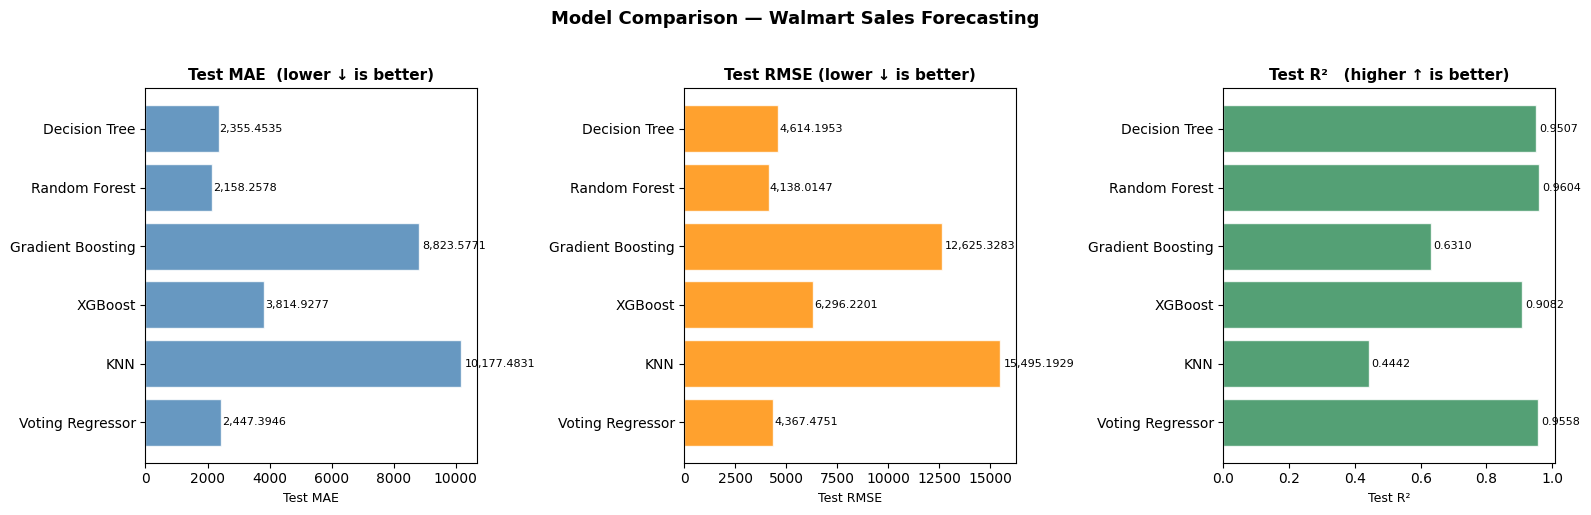

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_pairs = [
    ('Test MAE',  'Test MAE  (lower ↓ is better)',  'steelblue'),
    ('Test RMSE', 'Test RMSE (lower ↓ is better)',  'darkorange'),
    ('Test R²',   'Test R²   (higher ↑ is better)', 'seagreen'),
]

for ax, (col, title, color) in zip(axes, metrics_pairs):
    vals  = df_results[col]
    bars  = ax.barh(vals.index, vals.values, color=color, alpha=0.82, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.invert_yaxis()
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_width() + abs(bar.get_width()) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{v:,.4f}', va='center', fontsize=8)

plt.suptitle('Model Comparison — Walmart Sales Forecasting', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [210]:
# Summary table
styled = df_results[['Test MAE','Test RMSE','Test R²','Train R²']].round(4)
styled['Rank (Test R²)'] = styled['Test R²'].rank(ascending=False).astype(int)
styled = styled.sort_values('Rank (Test R²)')
print("\n=== Model Ranking by Test R² (highest = best) ===")
print(styled.to_string())


=== Model Ranking by Test R² (highest = best) ===
                     Test MAE   Test RMSE  Test R²  Train R²  Rank (Test R²)
Model                                                                       
Random Forest       2158.2578   4138.0147   0.9604    0.9693               1
Voting Regressor    2447.3946   4367.4751   0.9558    0.9637               2
Decision Tree       2355.4535   4614.1953   0.9507    0.9635               3
XGBoost             3814.9277   6296.2201   0.9082    0.9130               4
Gradient Boosting   8823.5771  12625.3283   0.6310    0.6355               5
KNN                10177.4831  15495.1929   0.4442    0.5580               6


# Save Model

In [211]:
# Saving model to disk of random forest
joblib.dump(ereg, 'model.pkl')

['model.pkl']

# Load Model and Predict

In [212]:
model=joblib.load('model.pkl')
model.predict([[211.0963582,5,1,2.572,0,2,151315,1,42.31,0,2010]])

array([21619.29760455])

In [213]:
X_train.columns

Index(['CPI', 'Day', 'Dept', 'Fuel_Price', 'IsHoliday_True', 'Month', 'Size',
       'Store', 'Temperature', 'Unemployment', 'Year'],
      dtype='object')